In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

# Look at the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
# info() gives us a concise summary of the DataFrame, including the number of non-null entries and the data types of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Handling Missing Values

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Drop the 'customerID' column as it is not useful for prediction

In [5]:

df.drop('customerID', axis=1, inplace=True)

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# as we can see TotalCharges is an object type, we need to convert it to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# error='coerce' will convert any non-numeric values to NaN, which we can then handle appropriately.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
# check for null values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
# Drop those 11 rows with missing values
df.dropna(inplace=True)

### Transforming Text into Numbers (Encoding)

In [10]:
# Rule of Machine Learning: Algorithms only understand math. They don't know what "Yes" or "Fiber optic" means. We have to convert all those text columns into 1s and 0s.
df["Churn"]=df["Churn"].map({"Yes":1,"No": 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
# check for missing values
df['Churn'].isnull().sum()

np.int64(0)

Convert all other text columns into 1s and 0s

In [12]:
# for other categorical columns, we can use pd.get_dummies to convert them into dummy variables (one-hot encoding)
# This automatically finds all remaining 'object' columns and converts them into 1s and 0s
df = pd.get_dummies(df, drop_first=True)
# Look at your new Data Types!
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [13]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


# EDA

### Part 1: Visualizing the Imbalance

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20036\4041439667.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


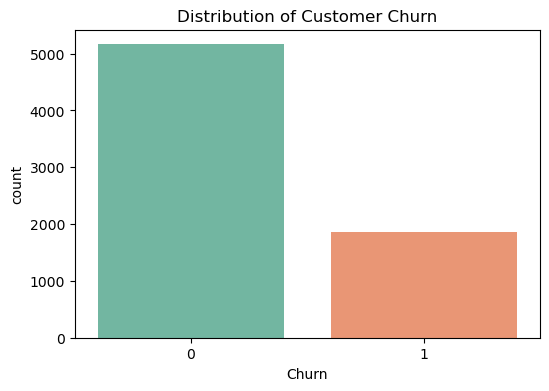

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize the Target Variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Distribution of Customer Churn")
plt.show()

# Print the exact percentages
print(df['Churn'].value_counts(normalize=True) * 100)

Key Observation

The target variable is imbalanced (~74% class 0, ~26% class 1). This likely contributes to the lower recall for churned customers and should be considered when selecting evaluation metrics and handling class imbalance.

### 2. The Golden Chart: Correlation to Churn

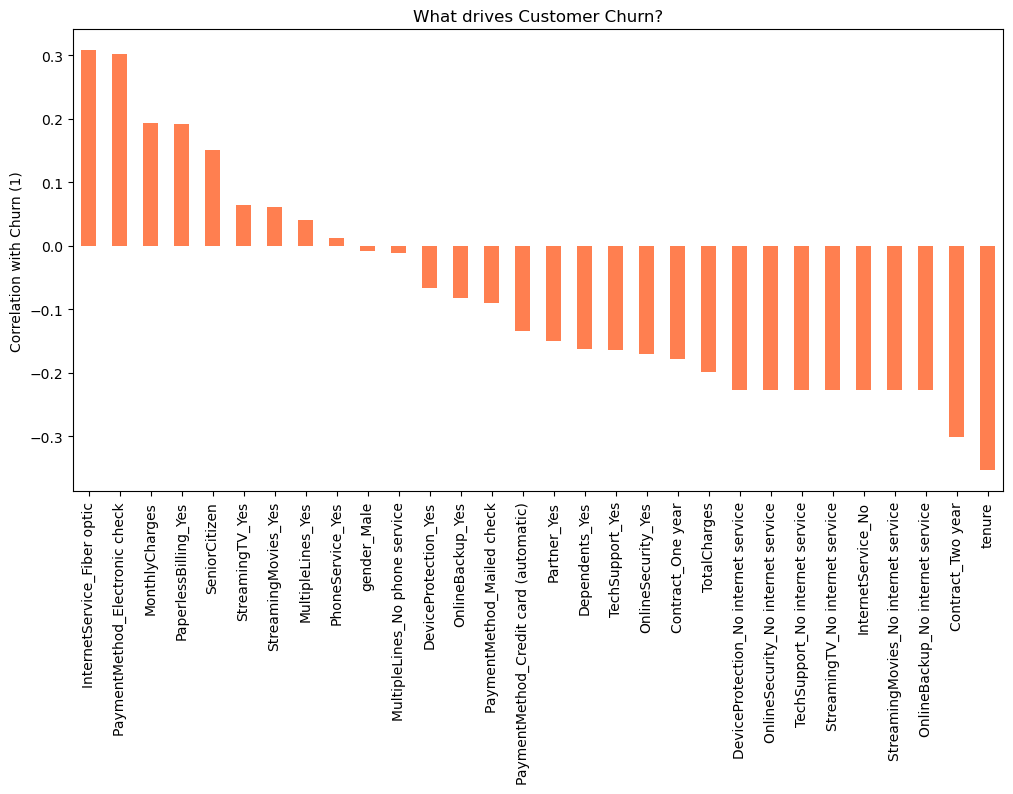

In [15]:
plt.figure(figsize=(12, 6))
# Calculate correlation, sort it, drop the Churn column itself, and plot
df.corr()['Churn'].sort_values(ascending=False).drop('Churn').plot(kind='bar', color='coral')
plt.title('What drives Customer Churn?')
plt.ylabel('Correlation with Churn (1)')
plt.show()

* Positive bars pointing up: Features that make a customer more likely to leave.
* Negative bars pointing down: Features that make a customer less likely to leave (loyalty drivers)

### 3. Deep Dive into "Tenure" (How long they have been a customer)

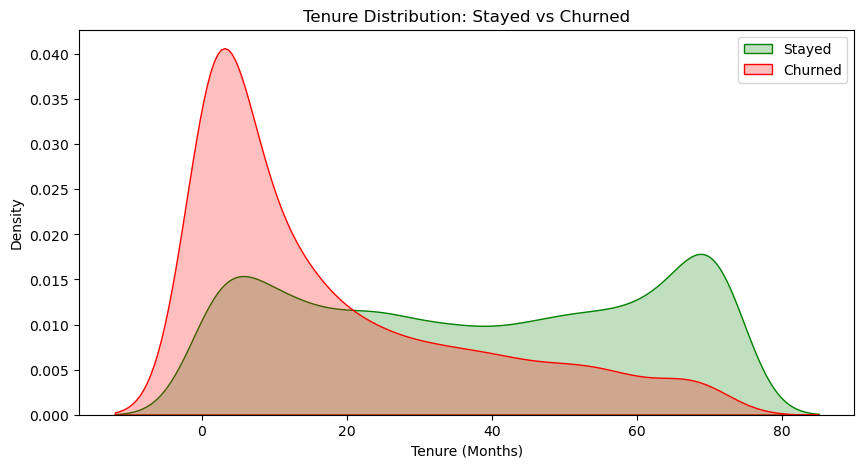

In [16]:
plt.figure(figsize=(10, 5))
# KDE plot shows the density (shape) of the data
sns.kdeplot(df[df['Churn'] == 0]['tenure'], label='Stayed', fill=True, color='green')
sns.kdeplot(df[df['Churn'] == 1]['tenure'], label='Churned', fill=True, color='red')
plt.title('Tenure Distribution: Stayed vs Churned')
plt.xlabel('Tenure (Months)')
plt.legend()
plt.show()

Insight: Tenure vs Churn

- Customers with low tenure are more likely to churn.
- Customers with high tenure are more likely to stay.
- Tenure is an important feature for churn prediction.
- Strong negative relationship: as tenure increases, churn probability decreases.

### Class Imbalance Handling

The dataset is imbalanced, with fewer churned customers (class 1) than non-churned customers (class 0). SMOTE is used to balance the training data by generating synthetic samples of the minority class, helping the model learn both classes more effectively.


### ⚠️ Golden Rule of SMOTE

Always follow:

1. Split the data into Train and Test sets.
2. Apply SMOTE only on the Training data.
3. Keep the Test data untouched.

Reason: Applying SMOTE before splitting causes Data Leakage. Synthetic samples may appear in both train and test sets, leading to unrealistically high performance and poor real-world results.

Remember:
**Split First → SMOTE Second → Train Model**


# 5. Feature Selection and Engineering

Total Number of Extra Services

We combine six service-related columns into a single feature (`Total_Extra_Services`) that represents how many additional services a customer subscribes to. This may help the model capture customer engagement and its relationship with churn.

In [17]:
# Define the columns that represent an extra service
service_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]

# Create our new feature by summing those columns horizontally (axis=1)
df['Total_Extra_Services'] = df[service_cols].sum(axis=1)

# Let's see if our new feature is actually useful!
# We will check its correlation with Churn
correlation = df['Total_Extra_Services'].corr(df['Churn'])
print(f"Correlation of Total_Extra_Services with Churn: {correlation:.3f}")

Correlation of Total_Extra_Services with Churn: -0.088


a negative number, proving that as the number of services goes UP, the chance of churning goes DOWN!

# Model Training.

Step 1: Split Features (X) from Target (y)

In [18]:
y=df["Churn"]              # ONLY the Churn column
X=df.drop("Churn",axis=1)  # Everything EXCEPT the Churn column

print(y.value_counts(normalize=True))
print("Features Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Features Dataset Shape: (7032, 31)
Target Dataset Shape: (7032,)


Step 2: The Train-Test Split

* X_train - Features for learning (Questions given for practice)
* y_train - Correct answer for learning(Answer key for practice questions)
* X_test - Unseen features(Questions in the final exam)
* y_test - Actual answer(Official answer sheet of the final exam)

In [19]:
from sklearn.model_selection import train_test_split

# Split into Training Data (80%) and Testing Data (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# `stratify=y` preserves the original class distribution in both the training and testing datasets. This is especially important for imbalanced datasets to ensure fair training and reliable evaluation.

print("Training Features shape:", X_train.shape)
print("Testing Features shape:", X_test.shape)

Training Features shape: (5625, 31)
Testing Features shape: (1407, 31)


Step 3: Scaling and SMOTE

In [20]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 3a: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Notice we only .transform() the test data!

# Step 3b: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n--- Target distribution BEFORE SMOTE ---")
print(y_train.value_counts())
print("\n--- Target distribution AFTER SMOTE ---")
print(y_train_resampled.value_counts())


--- Target distribution BEFORE SMOTE ---
Churn
0    4130
1    1495
Name: count, dtype: int64

--- Target distribution AFTER SMOTE ---
Churn
0    4130
1    4130
Name: count, dtype: int64


Step 4: Training the Random Forest Algorithm!

Model Accuracy: 77.75%

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



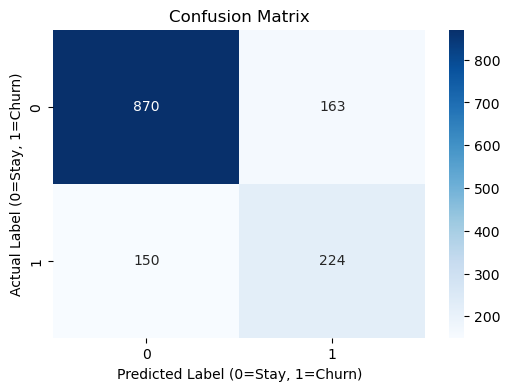

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# step 1 create the model
rf_model = RandomForestClassifier(random_state=42)  # New boarn baby

# step 2 Train the model
rf_model.fit(X_train_resampled, y_train_resampled)  # give some data to baby for learn

# step 3 Give data to model for predict
predictions =  rf_model.predict(X_test_scaled)  # give Quiz to and get answer

# step 4 Check the results
accuracy = accuracy_score(y_test,predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# step 5 Detailed report card
print(classification_report(y_test,predictions))

# step 6 Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label (0=Stay, 1=Churn)')
plt.xlabel('Predicted Label (0=Stay, 1=Churn)')
plt.show()

Step 5: Training the LogisticRegression Algorithm

Model Accuracy: 73.28%

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



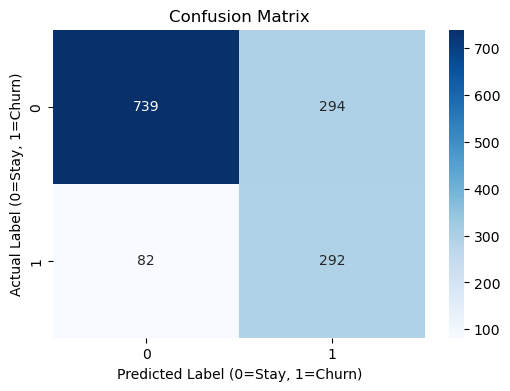

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# step 1 create the model
lr_model = LogisticRegression(random_state=42)  # New born baby

# step 2 Train the model
lr_model.fit(X_train_resampled, y_train_resampled)  # give some data to baby for learn

# step 3 Give data to model for predict
predictions = lr_model.predict(X_test_scaled)  # give Quiz and get answer

# step 4 Check the results
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# step 5 Detailed report card
print(classification_report(y_test, predictions))

# step 6 Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, predictions),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label (0=Stay, 1=Churn)')
plt.xlabel('Predicted Label (0=Stay, 1=Churn)')
plt.show()